In [ ]:
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list, optimal_leaf_ordering
result = pd.read_csv("./humanDMD/singlen/bootstrap/20/DE_Genes_rld.csv", index_col="Rownumber") \
       .drop(columns=["Unnamed: 0"], errors="ignore")
result = result.rename(columns={"log2FoldChange": "log2FC"})
result["-log(qvalue)"] = -np.log10(result["padj"])
result["qvalue"] = result["padj"]

In [ ]:
filtered = result[
    (result['padj'] < 0.05)
].copy()

filtered["sig"] = filtered["log2FC"].apply(
    lambda x: "up" if x > 1 else ("down" if x < -1 else "normal")
)
print("Up:", (filtered["sig"] == "up").sum())
print("Down:", (filtered["sig"] == "down").sum())
print("Max -log(qvalue) (up):", filtered.loc[filtered["sig"] == "up", "-log(qvalue)"].max())
print("Max -log(qvalue) (down):", filtered.loc[filtered["sig"] == "down", "-log(qvalue)"].max())


## Heatmap

#### special

✅ 找到 22 个 Type I IFN 相关通路：
 - GOBP_ANTIVIRAL_INNATE_IMMUNE_RESPONSE
 - GOBP_CELLULAR_RESPONSE_TO_INTERFERON_ALPHA
 - GOBP_CELLULAR_RESPONSE_TO_INTERFERON_BETA
 - GOBP_INTERFERON_ALPHA_PRODUCTION
 - GOBP_INTERFERON_BETA_PRODUCTION
 - GOBP_INTERFERON_MEDIATED_SIGNALING_PATHWAY
 - GOBP_ISG15_PROTEIN_CONJUGATION
 - GOBP_NEGATIVE_REGULATION_OF_INTERFERON_ALPHA_PRODUCTION
 - GOBP_NEGATIVE_REGULATION_OF_INTERFERON_BETA_PRODUCTION
 - GOBP_NEGATIVE_REGULATION_OF_TYPE_I_INTERFERON_MEDIATED_SIGNALING_PATHWAY
 - GOBP_NEGATIVE_REGULATION_OF_TYPE_I_INTERFERON_PRODUCTION
 - GOBP_POSITIVE_REGULATION_OF_INTERFERON_ALPHA_PRODUCTION
 - GOBP_POSITIVE_REGULATION_OF_INTERFERON_BETA_PRODUCTION
 - GOBP_POSITIVE_REGULATION_OF_TYPE_I_INTERFERON_MEDIATED_SIGNALING_PATHWAY
 - GOBP_POSITIVE_REGULATION_OF_TYPE_I_INTERFERON_PRODUCTION
 - GOBP_REGULATION_OF_TYPE_I_INTERFERON_MEDIATED_SIGNALING_PATHWAY
 - GOBP_RESPONSE_TO_INTERFERON_ALPHA
 - GOBP_RESPONSE_TO_INTERFERON_BETA
 - GOBP_RESPONSE_TO_TYPE_I_INTERFERON
 - GOB

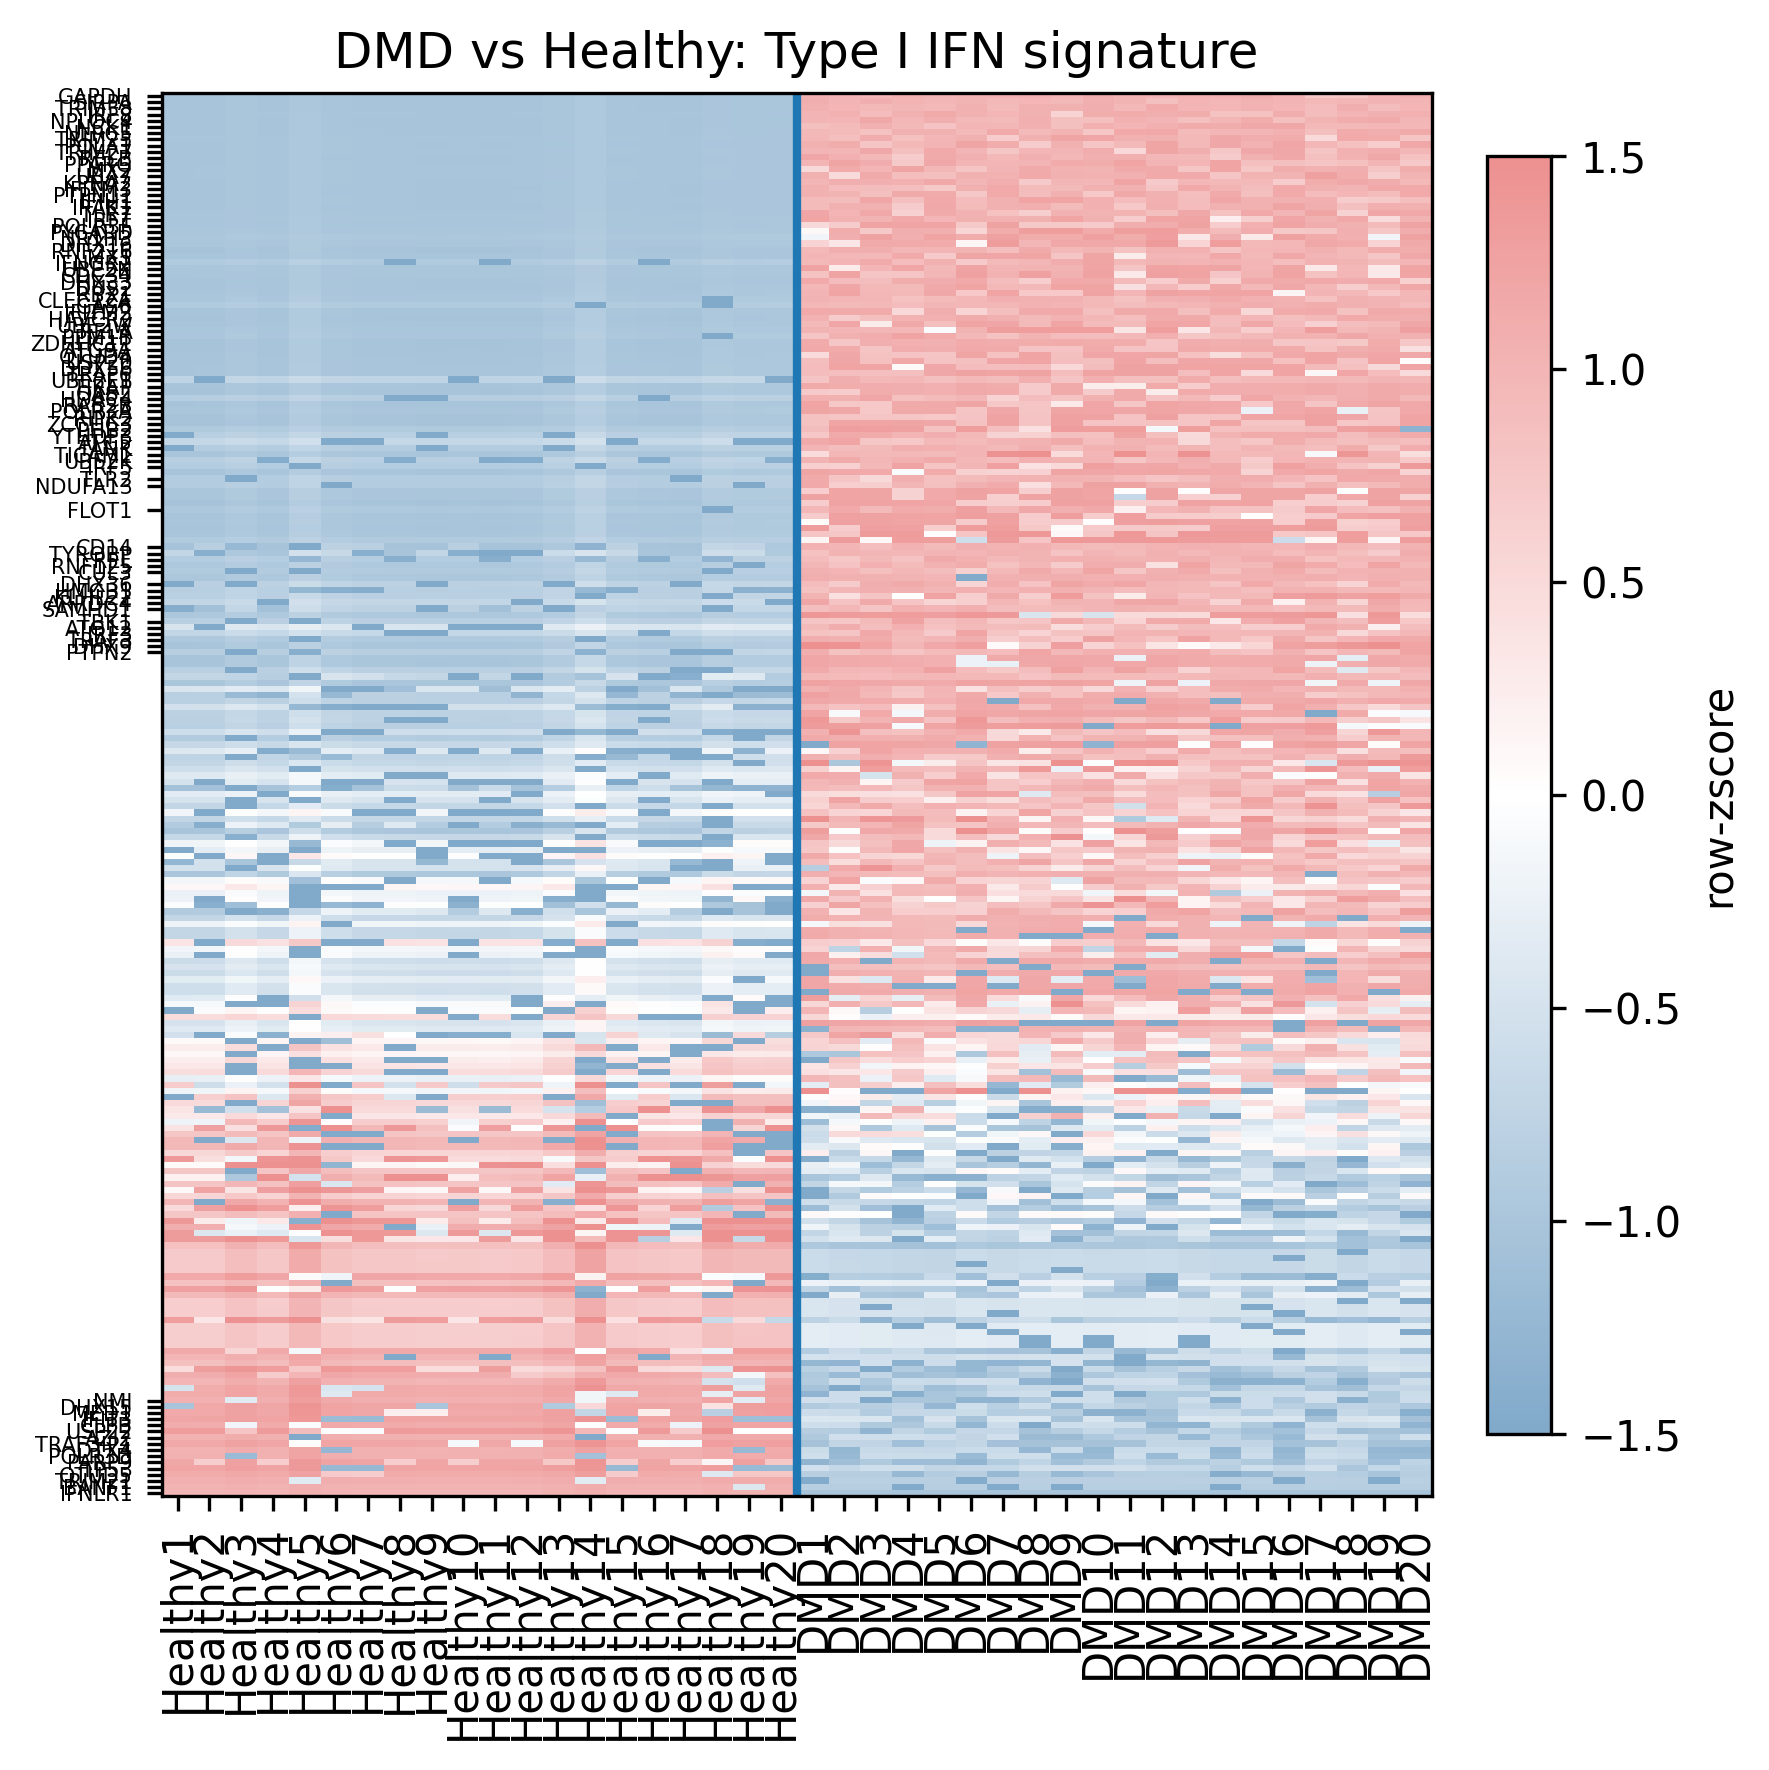

In [ ]:
import pandas as pd

gmt_file = "./humanDMD/c5.go.v2025.1.Hs.symbols.gmt"

keywords = [
    "interferon alpha",
    "interferon beta",
    "type i interferon",
    "type-i interferon",
    "type i ifn",
    "ifna",
    "ifnb",
    "antiviral",
    "isg15",
    "ifn",
    "interferon"
]
keywords = [k.lower() for k in keywords]

def contains_keywords(term):
    low = term.lower()
    return any(k in low for k in keywords)

def is_not_gamma(term):
    low = term.lower()
    return ("gamma" not in low) and ("ifng" not in low) and ("ii" not in low)

def clean_pathway_name(name):
    parts = name.split('_')
    if len(parts) > 1:
        return ' '.join(parts[1:])
    return name.replace('_', ' ')

pathways = {}
with open(gmt_file, "r") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) < 3:
            continue
        pathway_name = parts[0]
        genes = parts[2:]
        pathways[pathway_name] = genes

matched_pathways = {
    name: genes
    for name, genes in pathways.items()
    if contains_keywords(clean_pathway_name(name))
    and is_not_gamma(clean_pathway_name(name))
}

all_ifn_genes = sorted(set(
    g for genes in matched_pathways.values() for g in genes
))

for p in matched_pathways:
    print(" -", p)


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list, optimal_leaf_ordering
from matplotlib.colors import LinearSegmentedColormap
colors = ["#80A9CA", "#FFFFFF", "#ED9090"]
cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)
idx_upper_to_orig = {g.upper(): g for g in result.index.astype(str)}
requested_upper = [g.upper() for g in all_ifn_genes]

present_upper = [g for g in requested_upper if g in idx_upper_to_orig]
missing_upper = [g for g in requested_upper if g not in idx_upper_to_orig]

present_orig = [idx_upper_to_orig[g] for g in present_upper]

sub = result.loc[present_orig].copy()

def natural_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', str(s))]

dmd_cols = sorted([c for c in sub.columns if str(c).upper().startswith("DMD")], key=natural_key)
healthy_cols = sorted([c for c in sub.columns if str(c).upper().startswith("HEALTHY")], key=natural_key)

ordered_cols = healthy_cols + dmd_cols
sub = sub[ordered_cols]

vals = sub.values.astype(float)

row_mean = np.mean(vals, axis=1, keepdims=True)
row_std = np.std(vals, axis=1, ddof=0, keepdims=True)
row_std[row_std == 0] = 1.0

z_vals = (vals - row_mean) / row_std
z_df = pd.DataFrame(z_vals, index=sub.index, columns=ordered_cols)
log2fc_series = result.loc[present_orig, "log2FC"]

log2fc_series = log2fc_series.reindex(present_orig)

sorted_genes = log2fc_series.sort_values(ascending=False).index.tolist()

z_ord = z_df.loc[sorted_genes]
ytick_positions = []
ytick_labels = []

for i, g in enumerate(sorted_genes):
    if g in up_in_pathway:
        ytick_positions.append(i)
        ytick_labels.append(f"{g}")
    elif g in down_in_pathway:
        ytick_positions.append(i)
        ytick_labels.append(f"{g}")


plt.figure(figsize=(6, 6), dpi=300)
im = plt.imshow(z_ord.values, aspect="auto",cmap = cmap,vmax =1.5, vmin=-1.5)
plt.colorbar(im, fraction=0.046, pad=0.04, label="row-zscore")
plt.yticks(ytick_positions, ytick_labels, fontsize=5)

plt.xticks(range(len(z_df.columns)), z_df.columns, rotation=90)
if len(dmd_cols) > 0 and len(healthy_cols) > 0:
    plt.axvline(x=len(healthy_cols)-0.5, linewidth=2)
plt.title("DMD vs Healthy: Type I IFN signature")
plt.tight_layout()
plt.savefig(
    "DMD_vs_Healthy_TypeI_IFN_signature_human_singlenuclues.pdf",
    format="pdf",
    bbox_inches="tight",dpi = 300
)
plt.show()

=== Pathway Gene Summary ===
Total pathway genes: 301
Expressed genes in dataset: 227
Up-regulated genes: 80
Down-regulated genes: 16


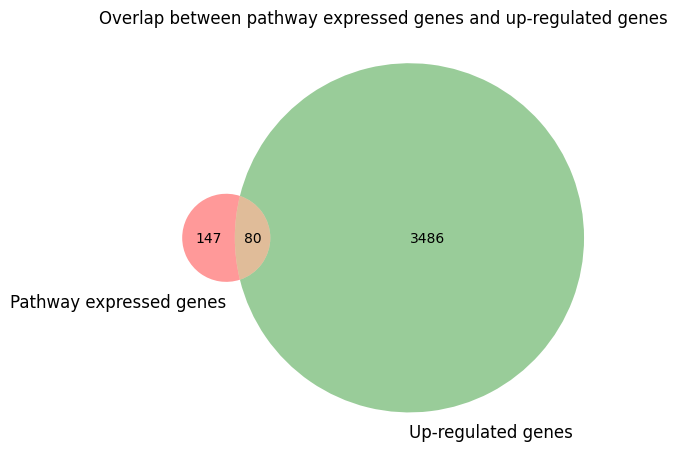

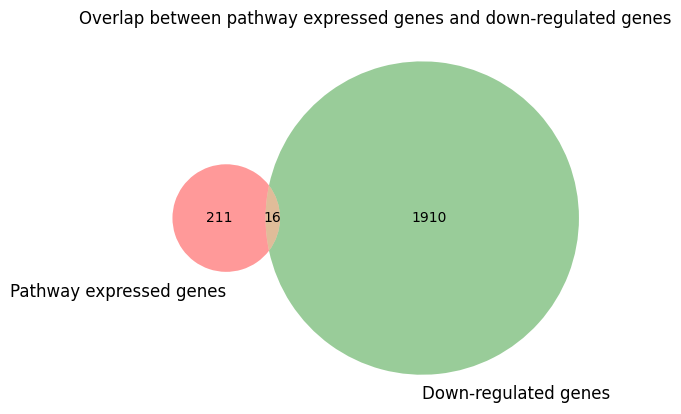

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# ===== 1. Pathway genes matched in your expression matrix =====
pathway_genes = set(present_orig)

# ===== 2. DEG results (example) — replace with your DEG lists =====
deg_up = set(filtered.query("log2FC > 1 & padj < 0.05").index)
deg_down = set(filtered.query("log2FC < -1 & padj < 0.05").index)

# ===== 3. Intersections =====
expressed_genes = pathway_genes
up_in_pathway = pathway_genes & deg_up
down_in_pathway = pathway_genes & deg_down

# ===== 4. Print summary =====
print("=== Pathway Gene Summary ===")
print(f"Total pathway genes: {len(all_ifn_genes)}")
print(f"Expressed genes in dataset: {len(expressed_genes)}")
print(f"Up-regulated genes: {len(up_in_pathway)}")
print(f"Down-regulated genes: {len(down_in_pathway)}")

# ===== 5. Venn diagram: expressed vs up-regulated =====
plt.figure(figsize=(6, 6))
venn2(subsets=(
        len(expressed_genes-up_in_pathway),  # only expressed
        len(deg_up-up_in_pathway),  # only up, usually 0
        len(up_in_pathway)                     # intersection
    ),
    set_labels=("Pathway expressed genes", "Up-regulated genes"),
)

plt.title("Overlap between pathway expressed genes and up-regulated genes")
plt.show()
# ===== 5. Venn diagram: expressed vs up-regulated =====
plt.figure(figsize=(6, 6))
venn2(subsets=(
        len(expressed_genes-down_in_pathway),  # only expressed
        len(deg_down-down_in_pathway),  # only up, usually 0
        len(down_in_pathway)                     # intersection
    ),
    set_labels=("Pathway expressed genes", "Down-regulated genes"),
)

plt.title("Overlap between pathway expressed genes and down-regulated genes")
plt.show()

In [ ]:
up_list = sorted(list(up_in_pathway))
down_list = sorted(list(down_in_pathway))

max_len = max(len(up_list), len(down_list))

up_list += [""] * (max_len - len(up_list))
down_list += [""] * (max_len - len(down_list))

df = pd.DataFrame({
    "up_overlap": up_list,
    "down_overlap": down_list
})

output_file = "human nucleus_pathway_deg_overlap_union.xlsx"
df.to_excel(output_file, index=False)

print("Saved to:", output_file)

In [8]:
from mpmath import *
import pandas as pd
mp.dps=500
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from mpmath import *
def c(a,b):
    a=mp.mpf(a)
    b=mp.mpf(b)
    cab = fac(a)/fac(a-b)/fac(b)
    return cab

def hyperp(N,n1,n2,k):
    N = mp.mpf(N)
    n1 = mp.mpf(n1)
    n2 = mp.mpf(n2)
    k = mp.mpf(k)
    p = c(n2,k)*c(N-n2,n1-k)/c(N,n1)
    return p 

def hypert(N,n1,n2,k):
    cdf = mp.mpf(0)
    for i in range(0,int(k)+1):
        cdf += hyperp(N,n1,n2,i)
       # print()
    return (1-cdf)

genesum = 14972
a = len(deg_up)
b = len(expressed_genes)
overlap = len(up_in_pathway)

p_value = hypert(genesum,a,b,overlap)
p_value

mpf('0.000034583838097107426737911253377240002948178477731925391578866487751513649798042637500752713984907147288969709685310438420219350419605047279749872454952236522718008568482762009701905355850086318932228162188746445477017572507390428297687313742132461680830643591576385905827072552664527728484386877028150719468329708097009222343322706430601478942599189939570476942443899146222796170394255262631282392703068442571489954588371924831342298022060340378361576753194689002226887207057825581393515903647776747694906')

In [9]:
genesum = 14972
a = len(expressed_genes)
b = len(deg_down)
overlap = len(down_in_pathway)

p_value = hypert(genesum,a,b,overlap)
p_value

mpf('0.99657633166653553764728869822585088651463627332874825924328548977672918767119494859264320466875754213418729504172554715568782466251682150159094750003890340043405804661049600289121459330849198851903221689239757258879796874528830389970339004533907795160313071630061963274193617517072752305472079328857920142622041335218050850423495199203508090986521669670199947143694656218095842440404834662934313599363850279094862893440328438098763331463455978566667199907721651057725993479217987985412609881497058023684')

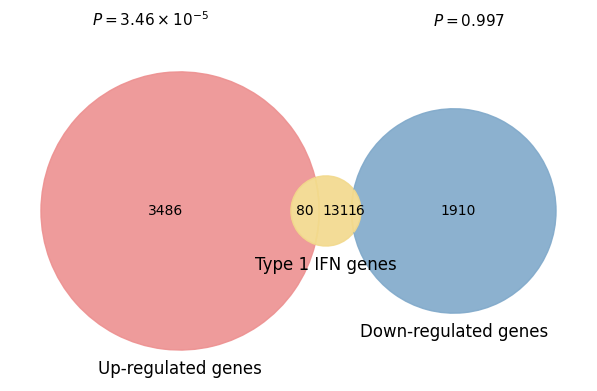

In [ ]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

pathway = set(expressed_genes)
up = set(deg_up)
down = set(deg_down)

plt.figure(figsize=(7, 4))
v = venn3(
    [pathway, up, down],
    set_labels=(
        "Type 1 IFN genes",
        "Up-regulated genes",
        "Down-regulated genes"
    )
)

v.get_patch_by_id('100').set_color('#F2D98C')  # pathway
v.get_patch_by_id('010').set_color('#ED9090')  # up
v.get_patch_by_id('001').set_color('#80A9CA')  # down
v.get_patch_by_id('110').set_color('#F2D98C')
v.get_patch_by_id('101').set_color('#F2D98C')
# v.get_patch_by_id('011').set_color('#F2D98C')
# v.get_patch_by_id('111').set_color('#F2D98C')

for p in v.patches:
    if p:
        p.set_alpha(0.9)

plt.text(-0.6, 0.6, r"$P = 3.46 \times 10^{-5}$", fontsize=11)
plt.text(0.5, 0.6, r"$P = 0.997$", fontsize=11)
plt.tight_layout()
plt.savefig(
    "venn_human_singlenuclues.pdf",
    format="pdf",
    bbox_inches="tight",dpi = 300
)
plt.show()
